In [151]:
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.table import Table, vstack
from astropy.io import fits
from IPython.display import display, clear_output
import csv
import pandas as pd
import glob

In [152]:
# Load FP catalog
fp_catalog_path = '/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/FP/Generating_Anchor_Points/gz_fp_comparison.csv'
gz_fp_comparison = pd.read_csv(fp_catalog_path)
print(len(gz_fp_comparison))

122651


In [153]:
ID_COL = 'fp_targetid'
RA_COL = 'fp_ra'
DEC_COL = 'fp_dec'
MORPH_COL = 'morphology'

TARGET_PER_CLASS = 400

cutout_dir = '/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/FP/fpy3_cutouts'

out_dir = "/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/FP/Generating_Anchor_Points"

ELL_CSV  = os.path.join(out_dir, "fp_vi_elliptical_correct.csv")
SPI_CSV  = os.path.join(out_dir, "fp_vi_spiral_correct.csv")
LEN_CSV  = os.path.join(out_dir, "fp_vi_lenticular_correct.csv")
IRR_CSV  = os.path.join(out_dir, "fp_vi_irregular_correct.csv")
INC_CSV  = os.path.join(out_dir, "fp_vi_incorrect.csv")

INSPECTED_FILE = os.path.join(out_dir, "fp_vi_inspected_ids.txt")

In [154]:
# load in existing counts

def load_count(csv_path):
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        return len(df)
    return 0

class_counts = {
    "Elliptical": load_count(ELL_CSV),
    "Spiral": load_count(SPI_CSV),
    "Lenticular": load_count(LEN_CSV),
    "Irregular": load_count(IRR_CSV),
}

print("Starting counts (including previous sessions):")
for k, v in class_counts.items():
    print(f"{k}: {v} / {TARGET_PER_CLASS}")

Starting counts (including previous sessions):
Elliptical: 400 / 400
Spiral: 400 / 400
Lenticular: 400 / 400
Irregular: 400 / 400


In [145]:
# show inspected ids
inspected_ids = set()

if os.path.exists(INSPECTED_FILE):
    with open(INSPECTED_FILE, "r") as f:
        for line in f:
            inspected_ids.add(line.strip())

In [146]:
def cutout_path(row):
    """
    Locate the FITS file for this galaxy.
    Filenames look like:
        <targetid>_grz_152_<RA>_<DEC>.fits
    """
    tid = row[ID_COL]
    pattern = os.path.join(cutout_dir, f"{tid}_grz_152_*.fits")
    matches = glob.glob(pattern)
    if len(matches) == 0:
        raise FileNotFoundError(f"No cutout found for targetid {tid} with pattern {pattern}")
    return matches[0]

def load_image(path):
    with fits.open(path) as hdul:
        data = hdul[0].data

    if data.ndim == 3 and data.shape[0] == 3:
        img = np.transpose(data, (1,2,0))
        g_img, r_img, z_img = img[:,:,0], img[:,:,1], img[:,:,2]
    else:
        img = data
        g_img = r_img = z_img = data
    return img, g_img, r_img, z_img

def display_image(row):
    path = cutout_path(row)
    img, g_img, r_img, z_img = load_image(path)

    print(f"TARGETID: {row[ID_COL]}")
    print(f"RA, DEC : {row[RA_COL]:.5f}, {row[DEC_COL]:.5f}")
    print(f"Predicted morphology (Galaxy Zoo): {row[MORPH_COL]}")
    print("-" * 50)

    plt.figure(figsize=(10, 8))
    plt.subplot(2,2,1)
    plt.imshow(img, origin="lower")
    plt.title("RGB (approx)")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(g_img, origin="lower", cmap="Greens")
    plt.title("g")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(r_img, origin="lower", cmap="Reds")
    plt.title("r")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(z_img, origin="lower", cmap="Purples")
    plt.title("z")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [147]:
ell_rows = []
spi_rows = []
len_rows = []
irr_rows = []
inc_rows = []
new_inspected_ids = set()

In [148]:
def append_rows_to_csv(rows, csv_path):
    if not rows:
        return
    new_df = pd.DataFrame(rows)
    if os.path.exists(csv_path):
        old_df = pd.read_csv(csv_path)
        out_df = pd.concat([old_df, new_df], ignore_index=True)
    else:
        out_df = new_df
    out_df.to_csv(csv_path, index=False)

def save_all_and_exit():
    print("Saving results...")
    append_rows_to_csv(ell_rows, ELL_CSV)
    append_rows_to_csv(spi_rows, SPI_CSV)
    append_rows_to_csv(len_rows, LEN_CSV)
    append_rows_to_csv(irr_rows, IRR_CSV)
    append_rows_to_csv(inc_rows, INC_CSV)

    if new_inspected_ids:
        with open(INSPECTED_FILE, "a") as f:
            for tid in new_inspected_ids:
                f.write(f"{tid}\n")
    print("Done.")

In [149]:
import os, glob
import numpy as np
import pandas as pd

cutout_dir = "/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/FP/fpy3_cutouts"

# All cutout FITS files
cutout_files = glob.glob(os.path.join(cutout_dir, "*_grz_152_*.fits"))
print("Number of cutout FITS files:", len(cutout_files))

# Extract the numeric ID before "_grz_"
cutout_ids = []
for path in cutout_files:
    base = os.path.basename(path)
    tid_str = base.split("_")[0]       # "2305843009213697379"
    cutout_ids.append(int(tid_str))

cutout_id_set = set(cutout_ids)
print("Example cutout IDs:", list(cutout_id_set)[:5])

Number of cutout FITS files: 160444
Example cutout IDs: [2842637887340544, 2843282371510273, 2842538977263618, 2842908222816256, 2842448220913664]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


TARGETID: 39627754391474731
RA, DEC : 351.90452, -1.41689
Predicted morphology (Galaxy Zoo): Lenticular
--------------------------------------------------


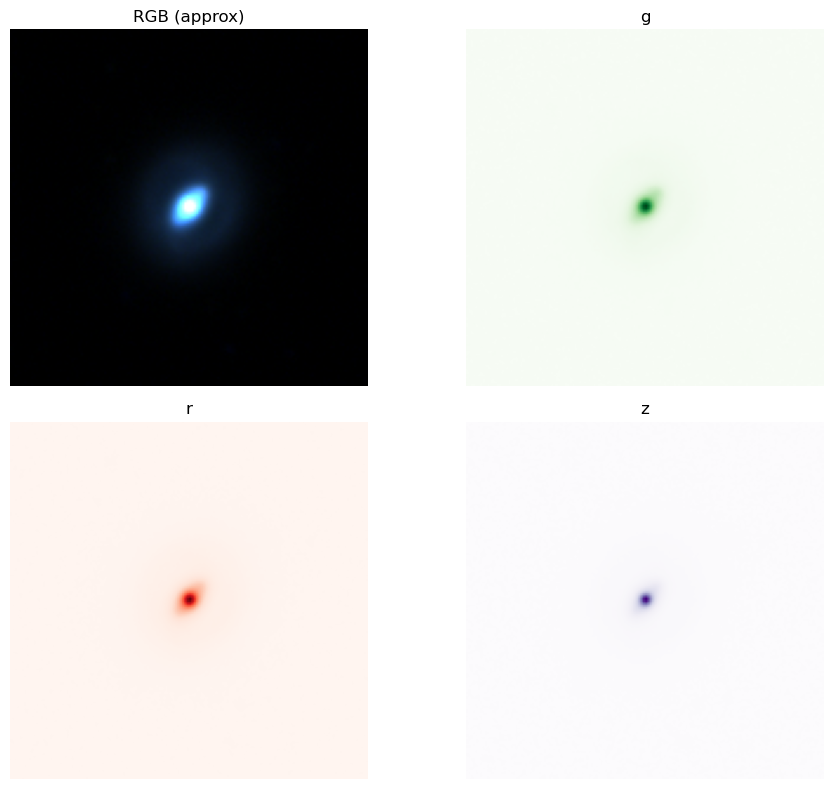

Correct? [y=yes, n=no, s=skip, stop=quit] :  y


All classes reached 1000! Stopping.
Saving results...
Done.
VI session complete.


In [150]:
remaining_indices = [
    idx for idx in gz_fp_comparison.index
    if str(gz_fp_comparison.loc[idx, ID_COL]) not in inspected_ids
]

np.random.shuffle(remaining_indices)

print(f"{len(remaining_indices)} galaxies available for inspection.")

running = True

while running and remaining_indices:

    # find next usable galaxy
    row = None

    while remaining_indices and row is None:
        idx = remaining_indices.pop()
        candidate = gz_fp_comparison.loc[idx]
        tid_str = str(candidate[ID_COL])
        morph = candidate[MORPH_COL]

        # already inspected?
        if tid_str in inspected_ids or tid_str in new_inspected_ids:
            continue

        # skip classes that have reached 1000
        if morph in class_counts and class_counts[morph] >= TARGET_PER_CLASS:
            continue

        row = candidate  # success

    # No valid rows left
    if row is None:
        print("All classes full or no remaining editable galaxies.")
        save_all_and_exit()
        break

    clear_output(wait=True)
    
    display_image(row)

    cmd = input("Correct? [y=yes, n=no, s=skip, stop=quit] : ").strip().lower()
    tid_str = str(row[ID_COL])
    morph = row[MORPH_COL]

    if cmd == "y":
        # correct classification → go into class-specific CSV
        if morph == "Elliptical":
            ell_rows.append(row.to_dict())
            class_counts["Elliptical"] += 1
        elif morph == "Spiral":
            spi_rows.append(row.to_dict())
            class_counts["Spiral"] += 1
        elif morph == "Lenticular":
            len_rows.append(row.to_dict())
            class_counts["Lenticular"] += 1
        elif morph == "Irregular":
            irr_rows.append(row.to_dict())
            class_counts["Irregular"] += 1
        else:
            inc_rows.append(row.to_dict())
        new_inspected_ids.add(tid_str)

    elif cmd == "n":
        inc_rows.append(row.to_dict())
        new_inspected_ids.add(tid_str)

    elif cmd == "s":
        continue

    elif cmd == "stop":
        running = False
        save_all_and_exit()
        break

    # After each classification, check goal
    all_full = all(class_counts[c] >= TARGET_PER_CLASS
                   for c in ["Elliptical", "Spiral", "Lenticular", "Irregular"])
    if all_full:
        print("All classes reached 1000! Stopping.")
        save_all_and_exit()
        break

print("VI session complete.")

In [155]:
ELL_CSV = os.path.join(out_dir, "fp_vi_elliptical_correct.csv")
SPI_CSV = os.path.join(out_dir, "fp_vi_spiral_correct.csv")
LEN_CSV = os.path.join(out_dir, "fp_vi_lenticular_correct.csv")
IRR_CSV = os.path.join(out_dir, "fp_vi_irregular_correct.csv")

# Read each file
df_ell = pd.read_csv(ELL_CSV)
df_spi = pd.read_csv(SPI_CSV)
df_len = pd.read_csv(LEN_CSV)
df_irr = pd.read_csv(IRR_CSV)

# add morphology label
df_ell["morphology"] = "elliptical"
df_spi["morphology"] = "spiral"
df_len["morphology"] = "lenticular"
df_irr["morphology"] = "irregular"

# Concatenate
df_all = pd.concat([df_ell, df_spi, df_len, df_irr], ignore_index=True)

# Save combined file
OUT_CSV = os.path.join(out_dir, "fp_vi_all_morphologies.csv")
df_all.to_csv(OUT_CSV, index=False)

print(f"Saved combined catalog to: {OUT_CSV}")

Saved combined catalog to: /pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/FP/Generating_Anchor_Points/fp_vi_all_morphologies.csv
